In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [54]:
# Load the dataset
df = pd.read_csv(r'C:\Python\Weather Data.csv')

In [28]:
# Display top records
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [29]:
# Display top records
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [42]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [30]:
# Distribution of Weather classes
df['Weather'].value_counts()

Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle                

In [31]:
# Check for data quality issues
print("Basic Statistics:")
print(df.describe())

Basic Statistics:
            Temp_C  Dew Point Temp_C    Rel Hum_%  Wind Speed_km/h  \
count  8784.000000       8784.000000  8784.000000      8784.000000   
mean      8.798144          2.555294    67.431694        14.945469   
std      11.687883         10.883072    16.918881         8.688696   
min     -23.300000        -28.500000    18.000000         0.000000   
25%       0.100000         -5.900000    56.000000         9.000000   
50%       9.300000          3.300000    68.000000        13.000000   
75%      18.800000         11.800000    81.000000        20.000000   
max      33.000000         24.400000   100.000000        83.000000   

       Visibility_km    Press_kPa  
count    8784.000000  8784.000000  
mean       27.664447   101.051623  
std        12.622688     0.844005  
min         0.200000    97.520000  
25%        24.100000   100.560000  
50%        25.000000   101.070000  
75%        25.000000   101.590000  
max        48.300000   103.650000  


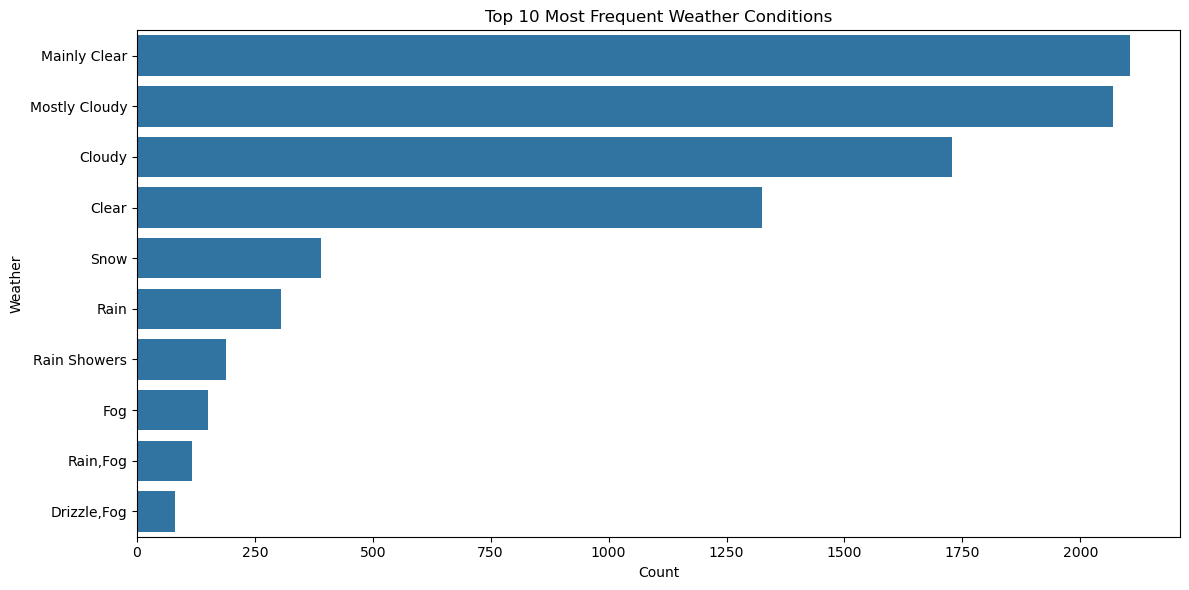

In [38]:
# Visualize the top weather classes
plt.figure(figsize=(12, 6))
top_weather = (df['Weather'].value_counts()).head(10)
sns.barplot(x=top_weather.values, y=top_weather.index)
plt.title('Top 10 Most Frequent Weather Conditions')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [55]:
# Separate features and target

X = df.drop(['Weather', 'Date/Time'], axis=1)
y = df['Weather']

In [65]:
# Train-test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=123)

In [57]:
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 6148
Test set size: 2636


In [69]:
# Modeling with Decision Trees for multiple max_depths

depths = list(range(1, 10)) + [None]
results = []

for d in depths:
    clf = Pipeline(steps=[('preproc', preprocessor),('clf', DecisionTreeClassifier(max_depth=d, random_state=42))])
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    results.append({'max_depth': d, 'train_accuracy': train_acc, 'test_accuracy': test_acc})

results_df = pd.DataFrame(results)

In [72]:
# train
clf.fit(X_train, y_train)

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Temp_C', 'Dew Point Temp_C',
                                                   'Rel Hum_%',
                                                   'Wind Speed_km/h',
                                                   'Visibility_km',
                                                   'Press_kPa']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('clf', DecisionTreeClassifier(random_state=42))])

In [73]:
# Convert None to a string for display purposes

results_df['max_depth_label'] = results_df['max_depth'].apply(lambda x: 'None' if x is None else str(x))

print("\nTrain vs Test accuracy for each max_depth:")
display(results_df[['max_depth_label', 'train_accuracy', 'test_accuracy']])


Train vs Test accuracy for each max_depth:


,max_depth_label,train_accuracy,test_accuracy
0,1.0,0.270007,0.270106
1,2.0,0.307254,0.299697
2,3.0,0.346454,0.324355
3,4.0,0.367111,0.339530
4,5.0,0.398016,0.368741
5,6.0,0.426318,0.392640
6,7.0,0.462101,0.389985
7,8.0,0.505530,0.406677
8,9.0,0.547658,0.408574
9,nan,1.000000,0.423748


In [74]:
# Analysis: which depth performs best on test set?
best_row = results_df.loc[results_df['test_accuracy'].idxmax()]
best_depth = best_row['max_depth']
best_test_acc = best_row['test_accuracy']

print(f"\nBest max_depth by test accuracy: {best_depth} (test accuracy = {best_test_acc:.4f})")



Best max_depth by test accuracy: nan (test accuracy = 0.4237)



Classification report (best model on test set):
                                  precision    recall  f1-score   support

                           Clear       0.43      0.46      0.44       403
                          Cloudy       0.40      0.43      0.41       504
                         Drizzle       0.32      0.43      0.36        14
                     Drizzle,Fog       0.26      0.33      0.29        21
         Drizzle,Ice Pellets,Fog       0.00      0.00      0.00         0
                    Drizzle,Snow       0.00      0.00      0.00         1
                Drizzle,Snow,Fog       0.67      0.25      0.36         8
                             Fog       0.57      0.59      0.58        46
                Freezing Drizzle       0.00      0.00      0.00         4
            Freezing Drizzle,Fog       0.00      0.00      0.00         3
           Freezing Drizzle,Haze       0.50      1.00      0.67         1
           Freezing Drizzle,Snow       0.00      0.00      0.0

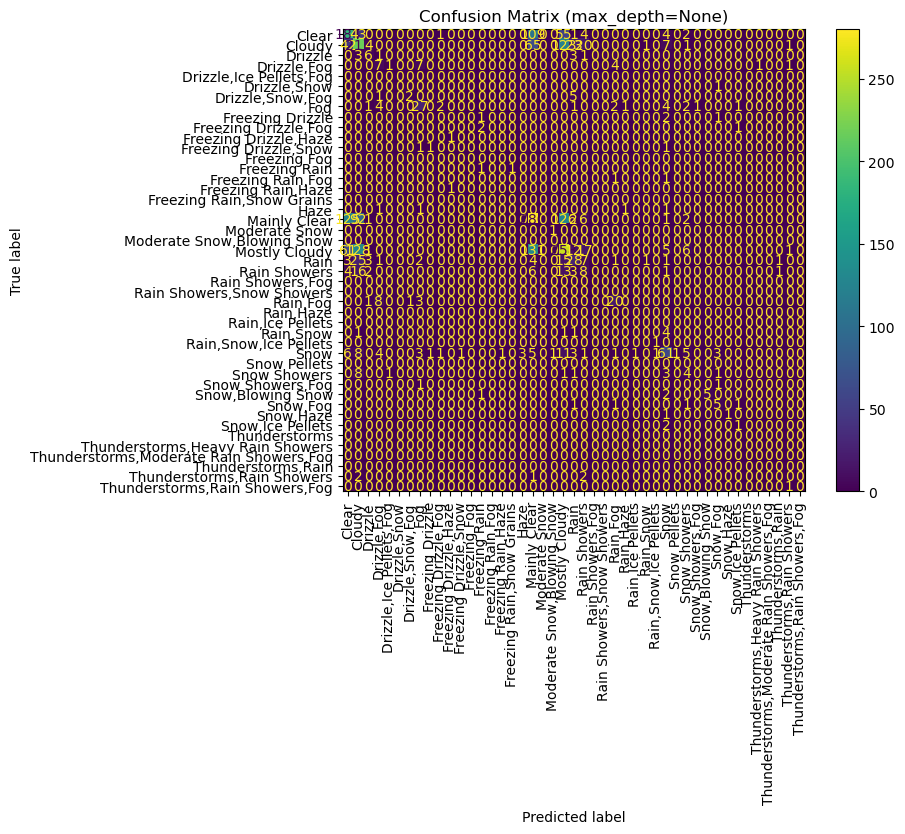

In [79]:
# Display confusion matrix and classification report for best model

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
best_clf = Pipeline(steps=[('preproc', preprocessor), ('clf', DecisionTreeClassifier(max_depth=best_depth, random_state=42))])
best_clf.fit(X_train, y_train)
y_test_pred_best = best_clf.predict(X_test)

print("\nClassification report (best model on test set):")
print(classification_report(y_test, y_test_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred_best, labels=best_clf.named_steps['clf'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_clf.named_steps['clf'].classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title(f'Confusion Matrix (max_depth={best_depth})')
plt.show()

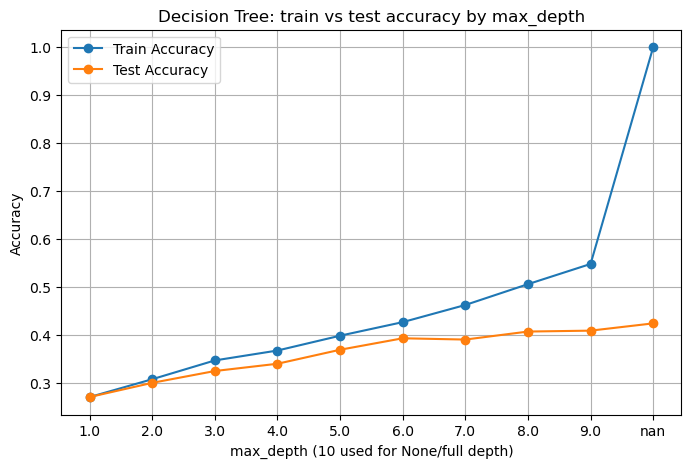

In [75]:
# Plotting accuracies vs depth (one plot)

plt.figure(figsize=(8,5))

# map None to a numeric value for plotting (use max depth + 1)
plot_x = [10 if d is None else d for d in depths]
plt.plot(plot_x, results_df['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(plot_x, results_df['test_accuracy'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth (10 used for None/full depth)')
plt.ylabel('Accuracy')
plt.title('Decision Tree: train vs test accuracy by max_depth')
plt.xticks(plot_x, results_df['max_depth_label'])
plt.legend()
plt.grid(True)
plt.show()

In [77]:
# Experiment with different max_depth values
max_depths = list(range(1, 10)) + [None]
train_accuracies = []
test_accuracies = []

print("Training Decision Trees with different depths:")
print("Depth\tTrain Acc\tTest Acc")
print("-" * 30)

for depth in max_depths:
    # Create and train decision tree
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    depth_display = "None" if depth is None else depth
    print(f"{depth_display}\t{train_acc:.4f}\t\t{test_acc:.4f}")

Training Decision Trees with different depths:
Depth	Train Acc	Test Acc
------------------------------
1	0.2700		0.2701
2	0.3073		0.2997
3	0.3465		0.3244
4	0.3671		0.3395
5	0.3980		0.3687
6	0.4263		0.3926
7	0.4621		0.3900
8	0.5055		0.4067
9	0.5477		0.4086
None	1.0000		0.4237


In [78]:
# Find the best performing depth

best_test_acc = max(test_accuracies)
best_depth_idx = test_accuracies.index(best_test_acc)
best_depth = max_depths[best_depth_idx]

print(f"\nBest Performance Analysis:")
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Best max_depth: {best_depth}")
print(f"Training accuracy at best depth: {train_accuracies[best_depth_idx]:.4f}")
print(f"Gap between train and test: {train_accuracies[best_depth_idx] - best_test_acc:.4f}")

# Analyze overfitting
print(f"\nOverfitting Analysis:")
print(f"Max depth None (unconstrained):")
print(f"  - Training accuracy: {train_accuracies[-1]:.4f}")
print(f"  - Test accuracy: {test_accuracies[-1]:.4f}")
print(f"  - Overfitting gap: {train_accuracies[-1] - test_accuracies[-1]:.4f}")


Best Performance Analysis:
Best test accuracy: 0.4237
Best max_depth: None
Training accuracy at best depth: 1.0000
Gap between train and test: 0.5763

Overfitting Analysis:
Max depth None (unconstrained):
  - Training accuracy: 1.0000
  - Test accuracy: 0.4237
  - Overfitting gap: 0.5763
